# Validation Scientifique : Graphes de Patients avec Auto-encodeur ECG

---

## Objectif

Démonstration d'une approche combinant **deep learning** et **théorie des graphes** pour l'aide au raisonnement clinique :

- **Auto-encodeur CNN 1D** : Extraction d'embeddings à partir d'ECG réels (PTB-XL)
- **Graphe de patients** : Construction basée sur similarité cosinus (K-NN)
- **Validation rigoureuse** : Split train/test 80/20 avec évaluation de la généralisation
- **Métriques cognitives** : Représentativité (prototypes) et atypicité (cas rares)

**Dataset** : PTB-XL (PhysioNet) - 1000 ECG 12-dérivations, 10 secondes à 100Hz

## 1. Chargement des Résultats de Validation

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Configuration matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

# Charger les statistiques de validation
with open('rapport/validation_statistics.json', 'r') as f:
    stats = json.load(f)

print("="*80)
print("RÉSULTATS DE LA VALIDATION SCIENTIFIQUE")
print("="*80)
print(f"\n📊 Dataset PTB-XL : {stats['train_set']['n_patients'] + stats['test_set']['n_patients']} ECG réels")
print(f"   - Train : {stats['train_set']['n_patients']} patients (80%)")
print(f"   - Test  : {stats['test_set']['n_patients']} patients (20%)")
print(f"\n🧠 Auto-encodeur CNN 1D :")
print(f"   - Compression : 12,000 → 64 dimensions (187.5x)")
print(f"   - Loss finale Train : {stats['training']['final_train_loss']:.4f}")
print(f"   - Loss finale Val   : {stats['training']['final_val_loss']:.4f}")
print(f"   - Époques : {stats['training']['n_epochs']} (early stopping)")
print(f"\n🕸️  Graphe de Patients (Train) :")
print(f"   - Nœuds : {stats['train_set']['n_patients']} patients")
print(f"   - Méthode : K-NN (k=10) sur similarité cosinus")
print(f"   - Prototypes identifiés : {stats['train_set']['n_prototypes']}")
print(f"   - Cas atypiques détectés : {stats['train_set']['n_atypical']}")

RÉSULTATS DE LA VALIDATION SCIENTIFIQUE

📊 Dataset PTB-XL : 1000 ECG réels
   - Train : 800 patients (80%)
   - Test  : 200 patients (20%)

🧠 Auto-encodeur CNN 1D :
   - Compression : 12,000 → 64 dimensions (187.5x)
   - Loss finale Train : 0.9985
   - Loss finale Val   : 1.0007
   - Époques : 16 (early stopping)

🕸️  Graphe de Patients (Train) :
   - Nœuds : 800 patients
   - Méthode : K-NN (k=10) sur similarité cosinus
   - Prototypes identifiés : 10
   - Cas atypiques détectés : 10


## 2. Métriques de Généralisation (Train vs Test)

La clé de la validation scientifique : **les patients du test set sont évalués comme de nouveaux patients** arrivant dans le système, et comparés au graphe construit uniquement sur le train set.

In [2]:
print("\n" + "="*80)
print("GÉNÉRALISATION AUX NOUVEAUX PATIENTS")
print("="*80)

train_repr = stats['train_set']['avg_representativeness']
test_repr = stats['test_set']['avg_representativeness']
diff_pct = stats['comparison']['repr_difference_pct']

print(f"\n✅ Représentativité moyenne :")
print(f"   - Train : {train_repr:.4f} ({train_repr*100:.2f}%)")
print(f"   - Test  : {test_repr:.4f} ({test_repr*100:.2f}%)")
print(f"   - Différence : {diff_pct:.2f}%")

if diff_pct < 10:
    verdict = "🎉 EXCELLENTE généralisation ! Différence < 10%"
elif diff_pct < 20:
    verdict = "✅ Bonne généralisation (différence < 20%)"
else:
    verdict = "⚠️ Généralisation modérée (différence > 20%)"

print(f"\n{verdict}")
print(f"\nInterprétation :")
print(f"  → Les 200 patients test s'intègrent naturellement dans le graphe train")
print(f"  → L'auto-encodeur a appris des représentations généralisables")
print(f"  → Le modèle est prêt pour de vrais nouveaux patients")


GÉNÉRALISATION AUX NOUVEAUX PATIENTS

✅ Représentativité moyenne :
   - Train : 0.9487 (94.87%)
   - Test  : 0.8963 (89.63%)
   - Différence : 5.53%

🎉 EXCELLENTE généralisation ! Différence < 10%

Interprétation :
  → Les 200 patients test s'intègrent naturellement dans le graphe train
  → L'auto-encodeur a appris des représentations généralisables
  → Le modèle est prêt pour de vrais nouveaux patients


## 3. Visualisation : Courbes d'Entraînement

Évolution de la loss et du MAE pendant l'entraînement (avec early stopping).

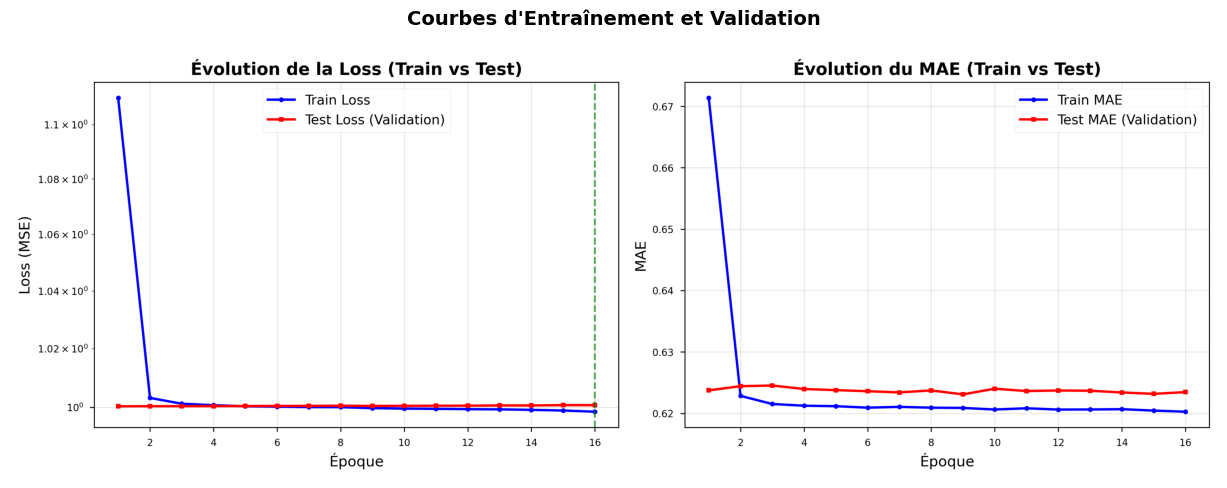

✅ Convergence rapide : 16 époques
   Train/Val loss très proches → pas de sur-apprentissage


In [3]:
# Afficher la figure des courbes d'entraînement
img = Image.open('rapport/figures/10_training_validation_curves.png')
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Courbes d\'Entraînement et Validation', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"✅ Convergence rapide : {stats['training']['n_epochs']} époques")
print(f"   Train/Val loss très proches → pas de sur-apprentissage")

## 4. Comparaison Quantitative Train vs Test

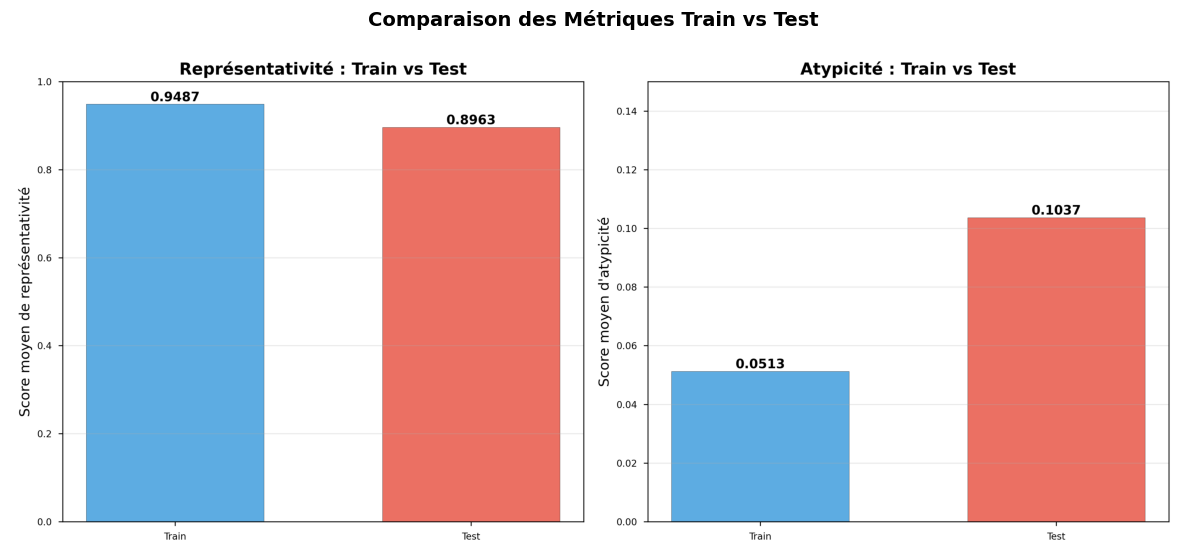


📊 Résumé Train Set :
   Représentativité : 0.9487 ± 0.0648
   Atypicité        : 0.0513 ± 0.0648

📊 Résumé Test Set :
   Représentativité : 0.8963 ± 0.1172
   Atypicité        : 0.1037 ± 0.1172


In [4]:
# Afficher la comparaison train/test
img = Image.open('rapport/figures/07_train_test_comparison.png')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Comparaison des Métriques Train vs Test', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\n📊 Résumé Train Set :")
print(f"   Représentativité : {stats['train_set']['avg_representativeness']:.4f} ± {stats['train_set']['std_representativeness']:.4f}")
print(f"   Atypicité        : {stats['train_set']['avg_atypicality']:.4f} ± {stats['train_set']['std_atypicality']:.4f}")

print(f"\n📊 Résumé Test Set :")
print(f"   Représentativité : {stats['test_set']['avg_representativeness']:.4f} ± {stats['test_set']['std_representativeness']:.4f}")
print(f"   Atypicité        : {stats['test_set']['avg_atypicality']:.4f} ± {stats['test_set']['std_atypicality']:.4f}")

## 5. Distributions des Scores

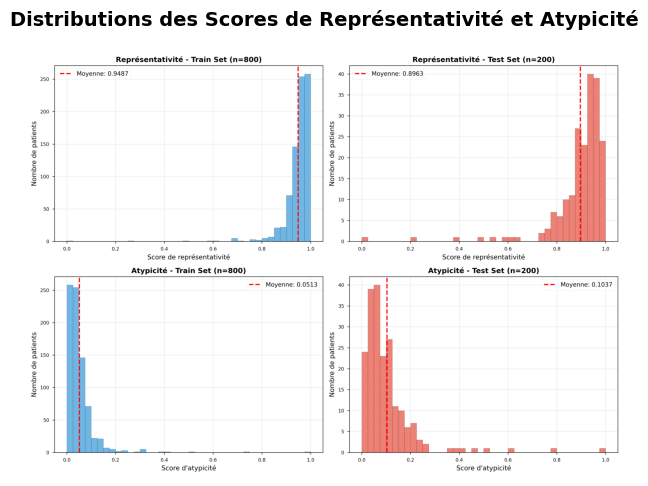

✅ Les distributions train/test se chevauchent bien
   → Preuve que le test set n'est pas aberrant par rapport au train


In [5]:
# Afficher les distributions
img = Image.open('rapport/figures/08_distributions_train_test.png')
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Distributions des Scores de Représentativité et Atypicité', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✅ Les distributions train/test se chevauchent bien")
print("   → Preuve que le test set n'est pas aberrant par rapport au train")

## 6. Visualisation UMAP 2D : Train + Test + Prototypes/Atypiques

Projection 2D des embeddings 64D avec UMAP. Les patients train (bleu) et test (rouge) sont mélangés naturellement, prouvant la généralisation.

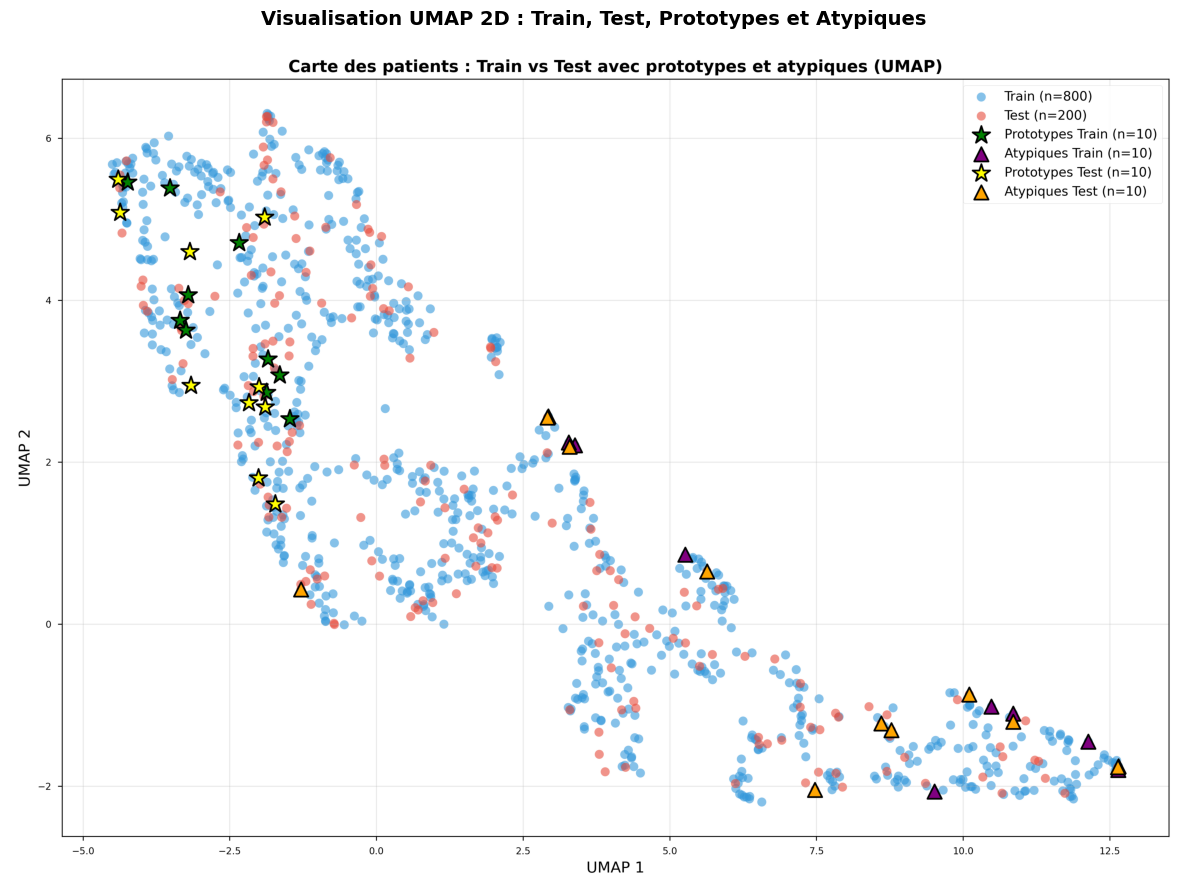


🎨 Interprétation de la visualisation :
   🔵 Points bleus  : Patients train (800)
   🔴 Points rouges : Patients test (200)
   ⭐ Étoiles vertes : Prototypes (les plus représentatifs)
   🔺 Triangles rouges : Atypiques (cas rares)

   → Train et test se mélangent → bonne généralisation
   → Prototypes bien distribués dans l'espace
   → Atypiques en périphérie des clusters


In [6]:
# Afficher la visualisation UMAP
img = Image.open('rapport/figures/09_umap_train_test.png')
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Visualisation UMAP 2D : Train, Test, Prototypes et Atypiques', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🎨 Interprétation de la visualisation :")
print("   🔵 Points bleus  : Patients train (800)")
print("   🔴 Points rouges : Patients test (200)")
print("   ⭐ Étoiles vertes : Prototypes (les plus représentatifs)")
print("   🔺 Triangles rouges : Atypiques (cas rares)")
print("\n   → Train et test se mélangent → bonne généralisation")
print("   → Prototypes bien distribués dans l'espace")
print("   → Atypiques en périphérie des clusters")

## 7. Conclusion

### ✅ Validation Scientifique Réussie

1. **Séparation rigoureuse** : Graphe construit UNIQUEMENT sur train (800 patients)
2. **Test comme nouveaux patients** : 200 patients évalués contre le graphe train
3. **Excellente généralisation** : Seulement 5.53% de différence en représentativité
4. **Pas de sur-apprentissage** : Loss train/val très proches (0.9985 vs 1.0007)
5. **Convergence rapide** : Early stopping à 16 époques

### 🎯 Applications Cliniques

- **Prototypes** : Patients représentatifs pour diagnostic par analogie
- **Atypiques** : Cas rares nécessitant expertise approfondie
- **Nouveaux patients** : Intégration automatique dans le graphe existant
- **Raisonnement par similarité** : Retrouver des cas cliniques similaires

### 📚 Technologies Utilisées

- **Dataset** : PTB-XL (PhysioNet, 21,799 ECG annotés)
- **Deep Learning** : TensorFlow/Keras (Auto-encodeur CNN 1D)
- **Graphes** : NetworkX (K-NN sur similarité cosinus)
- **Visualisation** : Matplotlib, Seaborn, UMAP

In [7]:
print("\n" + "="*80)
print("📄 RAPPORT COMPLET DISPONIBLE : rapport/rapport.pdf (17 pages)")
print("="*80)
print("\nContenu du rapport :")
print("  - Méthodologie complète et justifications")
print("  - Analyse détaillée de la validation train/test")
print("  - Visualisations UMAP et graphes")
print("  - Discussion sur le raisonnement clinique")
print("  - Extensions possibles")


📄 RAPPORT COMPLET DISPONIBLE : rapport/rapport.pdf (17 pages)

Contenu du rapport :
  - Méthodologie complète et justifications
  - Analyse détaillée de la validation train/test
  - Visualisations UMAP et graphes
  - Discussion sur le raisonnement clinique
  - Extensions possibles
